In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.splat as maf
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime
import os

from rubin_sim.splat.plots import bright_filter_colors

from rubin_sim.data import get_baseline
from os.path import basename


In [2]:
# Read in the current baseline
db_file = "desi_yearly_v5.3.5_10yrs.db"
run_name = basename(db_file).replace('.db', '')
con = sqlite3.connect(db_file)
df = pd.read_sql('select * from observations;', con)
con.close()
# Convert to a numpy array
visits_array = df.to_records(index=False)

In [3]:
# Looking at things vs time
info = {"run_name": run_name}
info["sub_data"] = "g band, not ToO, not DDF, exptime > 20s"
not_too = np.array(["ToO" not in note for note in visits_array["scheduler_note"]])
not_ddf = np.array(["DD" not in note for note in visits_array["scheduler_note"]])
indx = np.where((visits_array["band"] == "g") & (not_too == True) & (visits_array["visitExposureTime"] >= 20.)
               & (not_ddf == True))
sub_data = visits_array[indx]
times = np.arange(3653)
metric = maf.AccumulateCountMetric(times)
sl = maf.Slicer(nside=128, missing=0)
hp_time_array, info = sl(sub_data, metric, info=info)


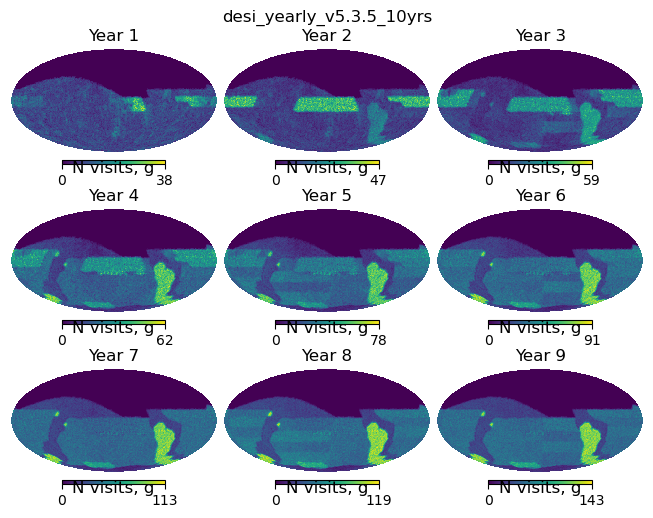

In [5]:
for i,year in enumerate(np.arange(1,10)):
    title_extra = ""
    if i == 1:
        title_extra = run_name + "\n"
    hp.mollview(hp_time_array[:,int(round(365.25*year))],
                title=title_extra + "Year %i" % year, unit="N visits, g",
                sub=(3,3, i+1))